In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.stattools import acf, pacf

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

SEED_VALUE = 1
import random
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

import warnings 
warnings.filterwarnings('ignore')

2026-06-26 18:34:03.472226: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782498843.674035      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782498843.731607      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782498844.211146      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782498844.211197      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782498844.211200      23 computation_placer.cc:177] computation placer alr

# 1a) EDA & Data Split

In [2]:
df = pd.read_csv("/kaggle/input/datasets/visednorm/uas-dl/Dataset C/GOOGL.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659000
1,2004-08-20,50.555557,54.594593,50.300301,54.209209,54.209209,22834300
2,2004-08-23,55.430431,56.796795,54.579578,54.754753,54.754753,18256100
3,2004-08-24,55.675674,55.855854,51.836838,52.487488,52.487488,15247300
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188600
...,...,...,...,...,...,...,...
3927,2020-03-26,1114.719971,1171.479980,1092.030029,1162.920044,1162.920044,3828100
3928,2020-03-27,1127.469971,1151.050049,1104.000000,1110.260010,1110.260010,3139700
3929,2020-03-30,1132.640015,1151.000000,1098.489990,1146.310059,1146.310059,2936800
3930,2020-03-31,1148.729980,1173.400024,1136.719971,1161.949951,1161.949951,3261400


In [3]:
df.shape

(3932, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3932 entries, 0 to 3931
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3932 non-null   object 
 1   Open       3932 non-null   float64
 2   High       3932 non-null   float64
 3   Low        3932 non-null   float64
 4   Close      3932 non-null   float64
 5   Adj Close  3932 non-null   float64
 6   Volume     3932 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 215.2+ KB


## Useless Columns

In [5]:
#only using Date and Close
df.drop(columns=['High', 'Open', 'Low', 'Adj Close', 'Volume'], inplace=True)
df.columns

Index(['Date', 'Close'], dtype='object')

## Duplicates

In [6]:
#checking dupes from Date
df['Date'].value_counts()

Date
2004-08-19    1
2004-08-20    1
2004-08-23    1
2004-08-24    1
2004-08-25    1
             ..
2020-03-26    1
2020-03-27    1
2020-03-30    1
2020-03-31    1
2020-04-01    1
Name: count, Length: 3932, dtype: int64

## Mismatch Data Types

In [7]:
#converting Date object to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3932 entries, 0 to 3931
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3932 non-null   datetime64[ns]
 1   Close   3932 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 61.6 KB


## Data Distribution

In [8]:
#checking descriptive statistics
df.describe()

,Date,Close
count,3932,3932.000000
mean,2012-06-09 06:50:54.323499520,509.072183
min,2004-08-19 00:00:00,50.055054
25%,2008-07-15 18:00:00,238.697449
50%,2012-06-07 12:00:00,327.722733
75%,2016-05-05 06:00:00,758.502487
max,2020-04-01 00:00:00,1524.869995
std,NaN,357.153459


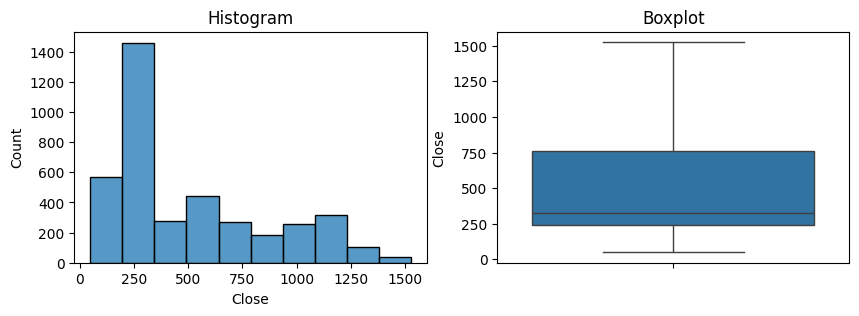

Skewness: 0.8895176037068703
Kurtosis: -0.44338191476649413


In [9]:
#checking Close distribution
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.histplot(df['Close'], bins=10)
plt.title('Histogram')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Close'])
plt.title('Boxplot')
plt.show()

print('Skewness:', df['Close'].skew())
print('Kurtosis:', df['Close'].kurt())

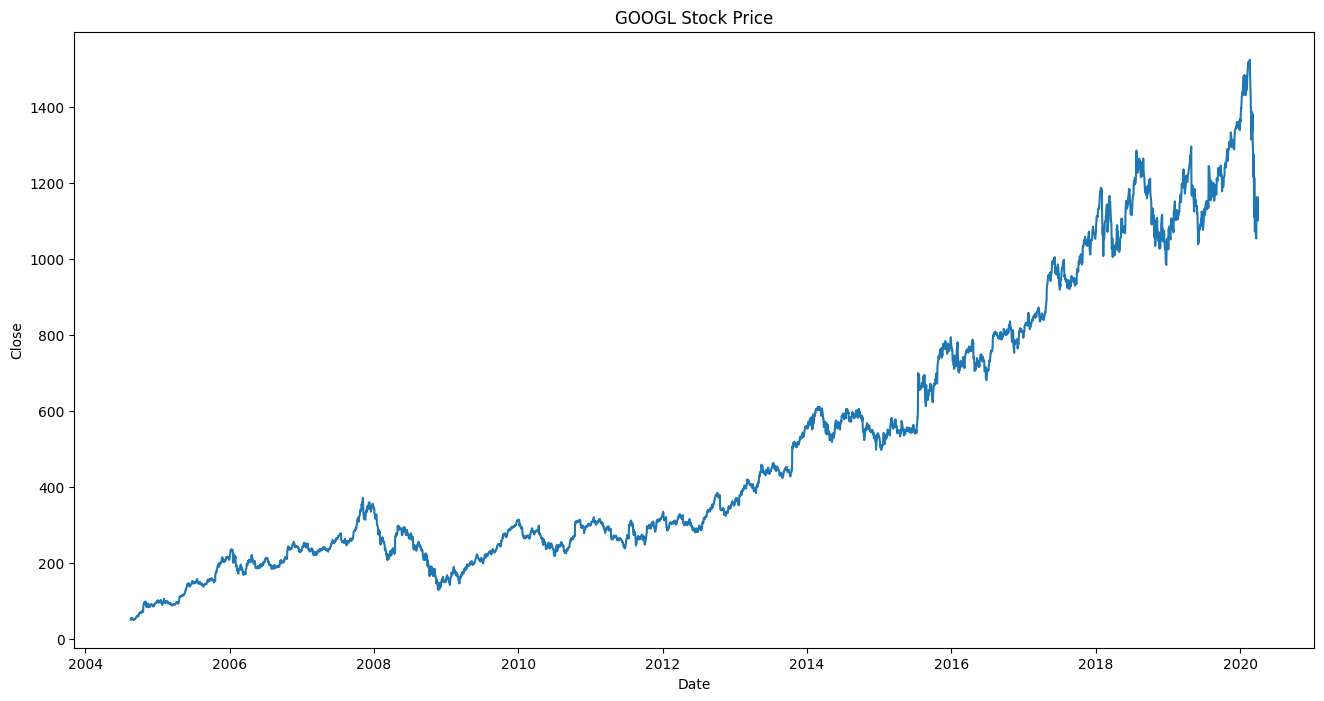

In [10]:
# plotting Close chart
plt.figure(figsize=(16,8))
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("GOOGL Stock Price")
plt.plot(df['Date'], df['Close'])
plt.show()

## Stationarity

In [11]:
def checkStationarity(df):
    #hitung rolling statistics
    rolmean = df.rolling(20).mean()
    rolstd = df.rolling(20).std()

    #plotting rolling statistics:
    original = plt.plot(df, color='black',label='Original')
    mean = plt.plot(rolmean, color='blue', label='Rolling Mean')
    std = plt.plot(rolstd, color='red', label = 'Rolling Std')
    
    plt.title('Rolling Mean and Standard Deviation Chart')
    plt.legend()
    plt.show()

    #cek Augmented Dickey-Fuller (ADF) test:
    print('== Dickey-Fuller Test ==')
    dftest = adfuller(df, autolag='AIC')
    
    dfoutput = pd.Series(dftest[0:2], index=['Test Statistic','p-value'])
    
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput, '\n')
    
    if dftest[1] <= 0.05:
        print("Data is stationary (p-value < 0.05)")
    else:
        print("Data is not stationary (p-value >= 0.05)")

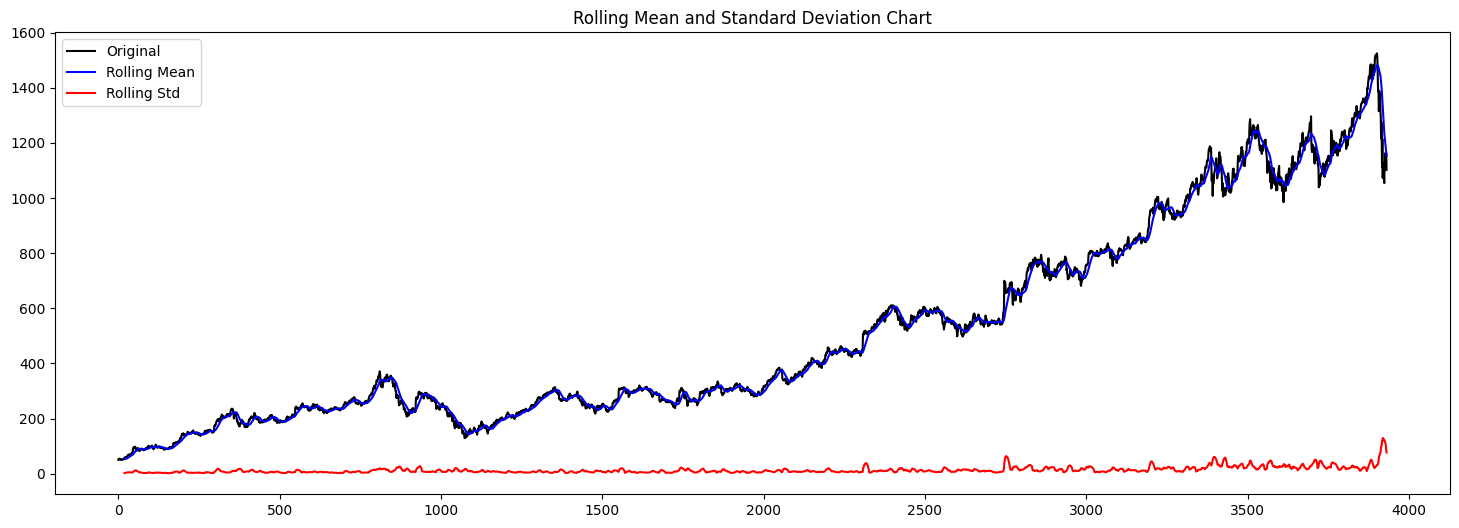

== Dickey-Fuller Test ==
Test Statistic         -0.504323
p-value                 0.891170
Critical Value (1%)    -3.432027
Critical Value (5%)    -2.862281
Critical Value (10%)   -2.567164
dtype: float64 

Data is not stationary (p-value >= 0.05)


In [12]:
plt.figure(figsize = (18,6))
checkStationarity(df['Close'])

Berdasarkan chart di atas, terlihat bahwa rolling mean terus-menerus meningkat seiring berjalannya waktu. Artinya, data time-series itu tidak stationary. Selain itu, hasil pengecekan ADF menunjukkan p-value >= 0.05, berarti null hypothesis tidak bisa ditolak. Hal ini diperkuat lagi dengan test statistic yang menunjukkan angka lebih dari crit value 5%, sehingga dengan 95% Confidence Interval, kita bisa yakin bahwa null hypothesis tidak boleh ditolak. Oleh karena itu, kita perlu melakukan transformasi data untuk membuat data menjadi stationary.

## Seasonality

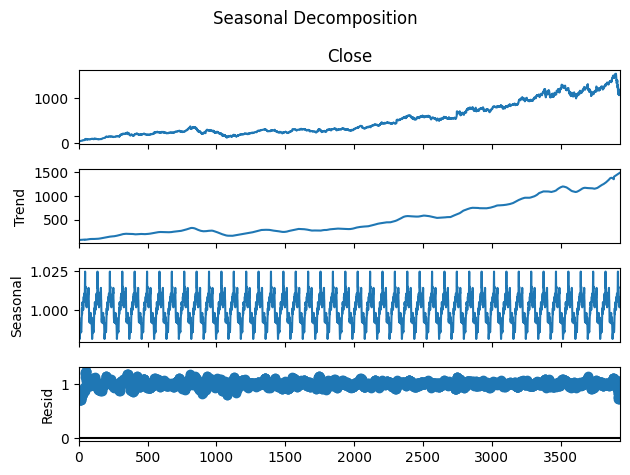

In [13]:
result = seasonal_decompose(
    df['Close'], 
    model='multiplicative', 
    extrapolate_trend='freq', 
    period=90
)
result.plot()

plt.suptitle('Seasonal Decomposition')
plt.tight_layout()
plt.show()

* Trend: Dalam jangka panjang, terlihat jelas bahwa Close price terus meningkat yang menunjukkan adanya trend ke atas.
* Seasonal: pola tiap kuartal (3 bulan) terlihat adanya ada siklus Close price cenderung turun sekitar 0.96 dan naik 1.06. Grafiknya juga konstan dan seragam dari awal sampai akhir karena penggunaan multiplicative.
* Residual: Lebar atau ketebalan band-nya sekarang relatif sama dan stabil.

Text(0.5, 1.0, 'Log Transformed Chart')

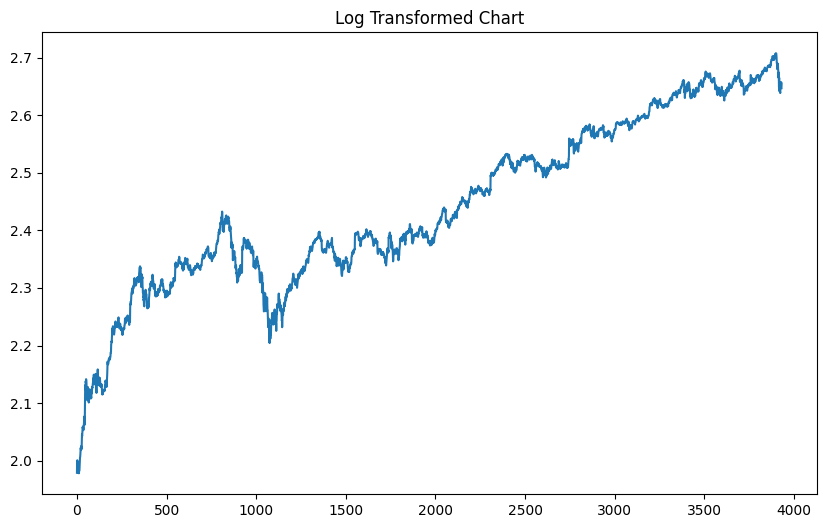

In [14]:
df_close_log = df['Close'].apply(np.log)
df_close_tf = df_close_log.apply(np.sqrt)

plt.figure(figsize = (10,6))
plt.plot(df_close_tf)
plt.title('Log Transformed Chart')

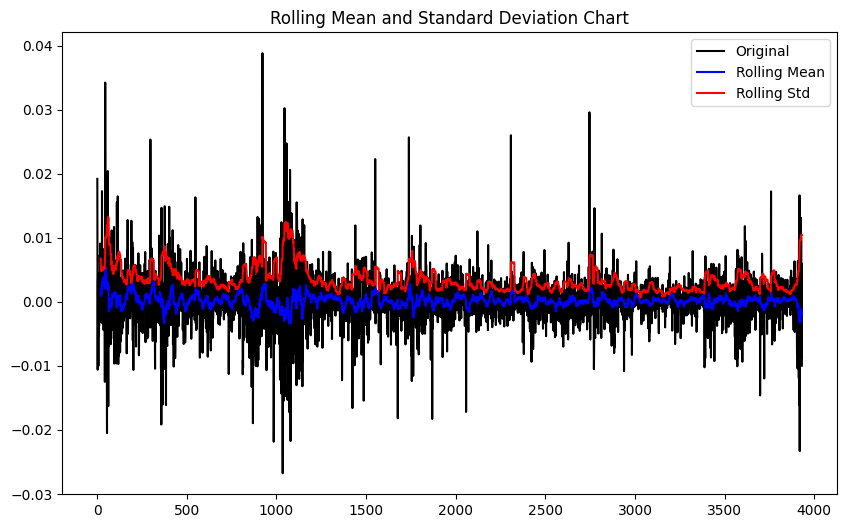

== Dickey-Fuller Test ==
Test Statistic         -1.730370e+01
p-value                 5.608596e-30
Critical Value (1%)    -3.432020e+00
Critical Value (5%)    -2.862278e+00
Critical Value (10%)   -2.567163e+00
dtype: float64 

Data is stationary (p-value < 0.05)


In [15]:
df_close_shift = df_close_tf - df_close_tf.shift()

df_close_shift.dropna(inplace=True)
plt.figure(figsize = (10,6))
checkStationarity(df_close_shift)

Setelah melakukan log transformation shifting pada data awal, terlihat bahwa hasil tes ADF sekarang sudah menandakan bahwa data bersifat stationary (p-value 5.6e-30 < 0.05). Selain itu, angka Test Statistic juga sekarang sudah jauh di bawah crit value 1%, sehingga dengan 99% CI bisa dikatakan bahwa data kita kini stationary.

## PACF

In [16]:
np.abs(pacf(df_close_shift,nlags=30))
print(np.where(np.abs(pacf(df['Close'],nlags=30))>0.05)[0])

[ 0  1  9 10 14 15 16 17 19 26 29]


## Windowing

In [17]:
def createWindow(sequence, days, feature):
    X, y = list(), list()
    for i in range(len(sequence)):
        horizon = i + days
        
        if horizon >= len(sequence):
            break
            
        seq_x, seq_y = sequence[i:horizon], sequence[horizon]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], feature))
    return X, y

In [18]:
window = 5
X, y = createWindow(df_close_shift.to_numpy(), window, 1)

X.shape, y.shape

((3926, 5, 1), (3926,))

## Train-Test Split

In [19]:
# train 90%, test 10%
split_idx = int(len(X) * 0.9)

X_train = X[:split_idx]
X_test = X[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]

print("Total:", len(X))
print("X_train:", X_train.shape, "y_train:", y_train.shape, round(y_train.shape[0]/len(X)*100,2), '%')
print("X_test :", X_test.shape, "y_test :", y_test.shape,  round(y_test.shape[0]/len(X)*100,2), '%')

Total: 3926
X_train: (3533, 5, 1) y_train: (3533,) 89.99 %
X_test : (393, 5, 1) y_test : (393,) 10.01 %


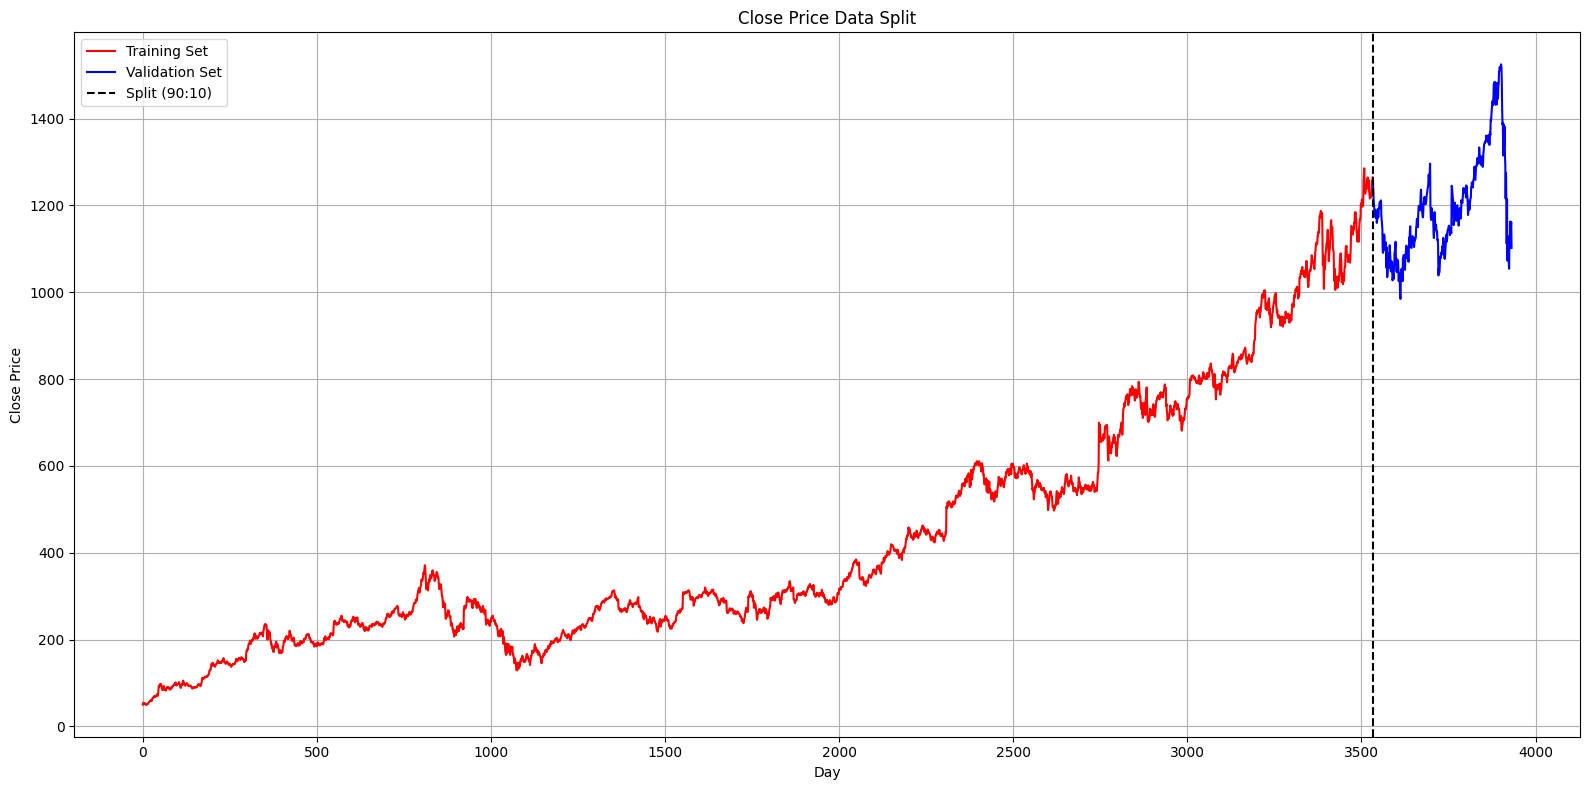

In [20]:
# visualisiasi train-test split
df_train = df[['Close']].iloc[:split_idx].values
df_valid = df[['Close']].iloc[split_idx:].values

plt.figure(figsize=(16, 8))

plt.plot(range(len(df_train)), df_train, label='Training Set', color='red')

start_idx = len(df_train)
end_idx = len(df_train) + len(df_valid)
plt.plot(range(start_idx, end_idx), df_valid, label='Validation Set', color='blue')

plt.axvline(x=split_idx, color='black', linestyle='--', label=f'Split (90:10)')

plt.title('Close Price Data Split')
plt.xlabel('Day')
plt.ylabel('Close Price')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# 1b) Baseline Model

## Baseline LSTM

In [21]:
model = Sequential(name="Baseline_LSTM")

model.add(LSTM(
    units=50, 
    activation='relu', 
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model.add(Dense(units=1, name="Output"))

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='mse',
    metrics=['mae']
)
model.summary()

I0000 00:00:1782498860.770378      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782498860.776286      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20


I0000 00:00:1782498864.119834      74 service.cc:152] XLA service 0x7dadb4009fe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782498864.119875      74 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782498864.119880      74 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782498864.510526      74 cuda_dnn.cc:529] Loaded cuDNN version 91002


 56/221 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7861e-05 - mae: 0.0028

I0000 00:00:1782498865.522654      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 1.6747e-05 - mae: 0.0028 - val_loss: 1.7233e-05 - val_mae: 0.0028
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.6697e-05 - mae: 0.0027 - val_loss: 1.7153e-05 - val_mae: 0.0028
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6698e-05 - mae: 0.0027 - val_loss: 1.7127e-05 - val_mae: 0.0028
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6698e-05 - mae: 0.0027 - val_loss: 1.7116e-05 - val_mae: 0.0028
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6699e-05 - mae: 0.0027 - val_loss: 1.7109e-05 - val_mae: 0.0028
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6699e-05 - mae: 0.0027 - val_loss: 1.7105e-05 - val_mae: 0.0028
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6699e-05 - mae: 0.0027 - val_loss: 1.7103e-05 - val_mae: 0.0028
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.6699e-05 - mae: 0.0027 - val_loss: 1.7101e-05 - val_mae: 0.0028
Ep

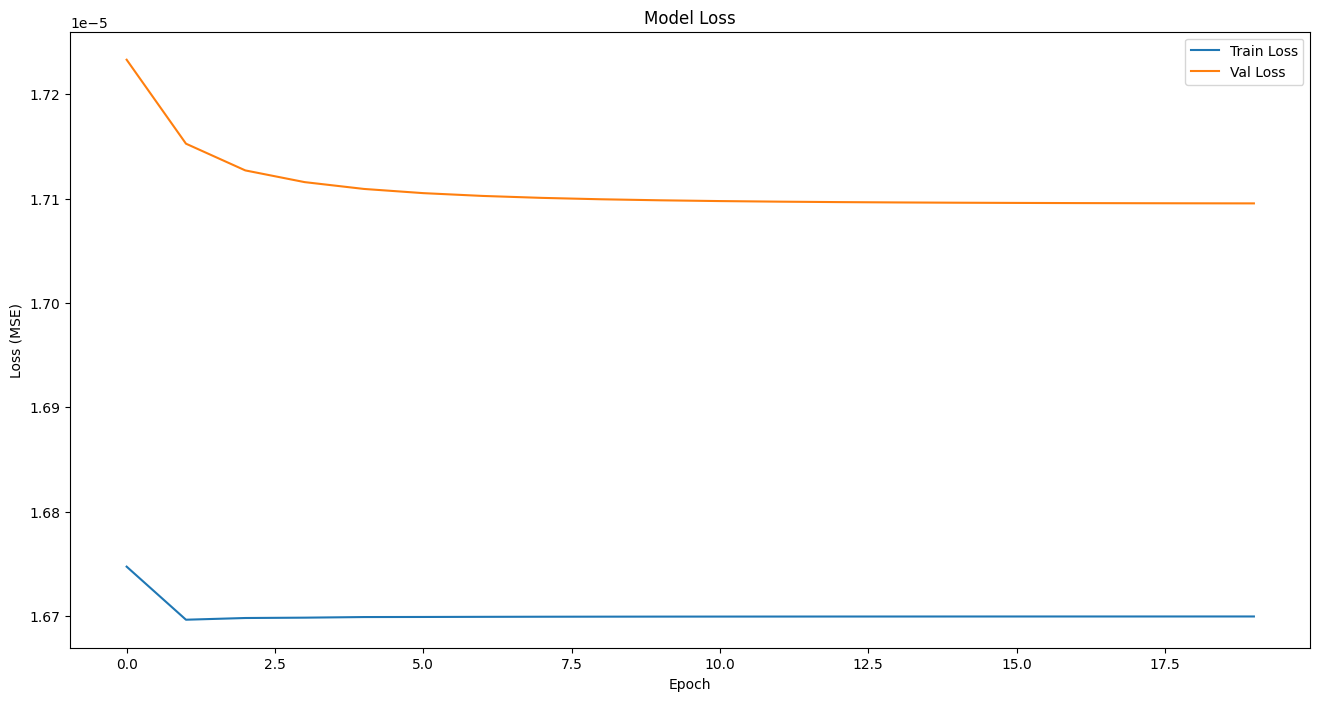

In [23]:
plt.figure(figsize=(16, 8))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [24]:
print("Test Set Evaluation")
results = model.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Test Set Evaluation
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7095e-05 - mae: 0.0028  
Test MSE: 1.7095373550546356e-05
Test MAE: 0.0028001561295241117


In [25]:
def inverseTransform(y_pred, y_test, df_original, df_transform):
    valid_dates = df_original.index[-len(y_pred):]

    pred_data = pd.DataFrame(index=valid_dates)
    pred_data['pred_raw'] = y_pred.flatten()
    pred_data['real_raw'] = y_test.flatten()

    # inverse diferensiasi
    shift_values = df_transform.shift().values[-len(y_pred):]
    pred_data['pred_log'] = pred_data['pred_raw'] + shift_values
    pred_data['real_log'] = pred_data['real_raw'] + shift_values

    # inverse sqrt to log
    pred_data['pred_sq'] = np.square(pred_data['pred_log'])
    pred_data['real_sq'] = np.square(pred_data['real_log'])

    # inverse log to real
    pred_data['pred'] = np.exp(pred_data['pred_sq'])
    pred_data['real'] = np.exp(pred_data['real_sq'])

    return pred_data[['real', 'pred']]

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


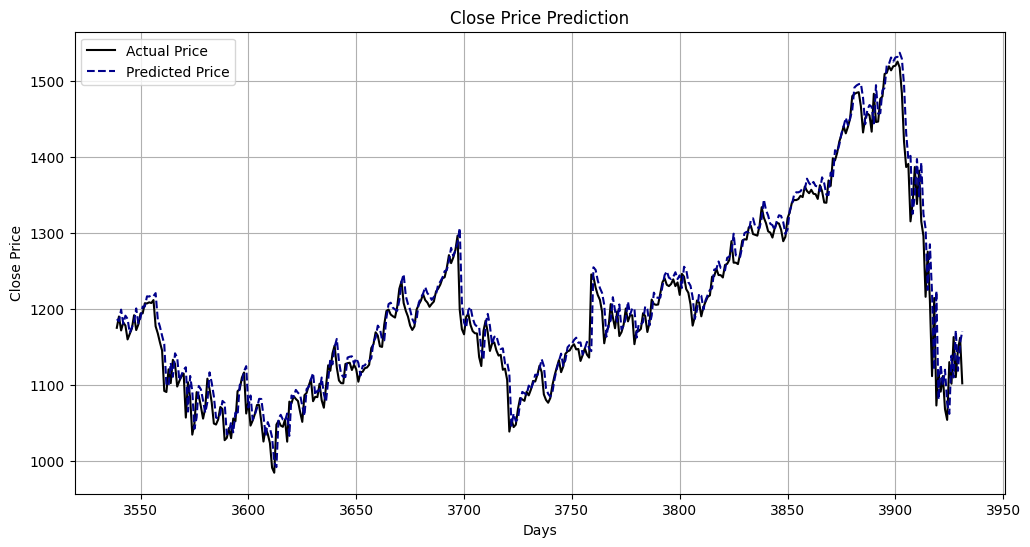

In [26]:
y_pred = model.predict(X_test)
df_result = inverseTransform(y_pred, y_test, df, df_close_tf)

plt.figure(figsize=(12, 6))
plt.grid()
plt.xlabel('Days')
plt.ylabel('Close Price')

plt.plot(df_result.index, df_result['real'], 'black', label='Actual Price')
plt.plot(df_result.index, df_result['pred'], 'darkblue', label='Predicted Price', linestyle='--')

plt.title('Close Price Prediction')
plt.legend()
plt.show()

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_true = df_result['real'].values
y_pred = df_result['pred'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100

print("Performance Metrics")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.3f}%")

Performance Metrics
MAE  : 17.706
RMSE : 25.993
MAPE : 1.503%


# 1c) Modified Model

## Modified LSTM

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model2 = Sequential(name="LSTM_modif")

model2.add(LSTM(
    units=50, 
    activation='relu', 
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model2.add(Dropout(0.2)) # Tambah Dropout
model2.add(Dense(units=1, name="Output"))

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mae']
)

model2.summary()

Model: "LSTM_modif"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train, y_train,
    epochs=100,              
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 1.6340e-05 - mae: 0.0027 - val_loss: 1.5152e-05 - val_mae: 0.0025
Epoch 2/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6326e-05 - mae: 0.0027 - val_loss: 1.5117e-05 - val_mae: 0.0025
Epoch 3/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6332e-05 - mae: 0.0027 - val_loss: 1.5085e-05 - val_mae: 0.0025
Epoch 4/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6318e-05 - mae: 0.0027 - val_loss: 1.5069e-05 - val_mae: 0.0025
Epoch 5/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6323e-05 - mae: 0.0027 - val_loss: 1.5066e-05 - val_mae: 0.0025
Epoch 6/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6322e-05 - mae: 0.0027 - val_loss: 1.5062e-05 - val_mae: 0.0025
Epoch 7/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6322e-05 - mae: 0.0027 - val_loss: 1.5063e-05 - val_mae: 0.0025
Epoch 8/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6329e-05 - mae: 0.0027 - val_loss: 1.5069e-05 -

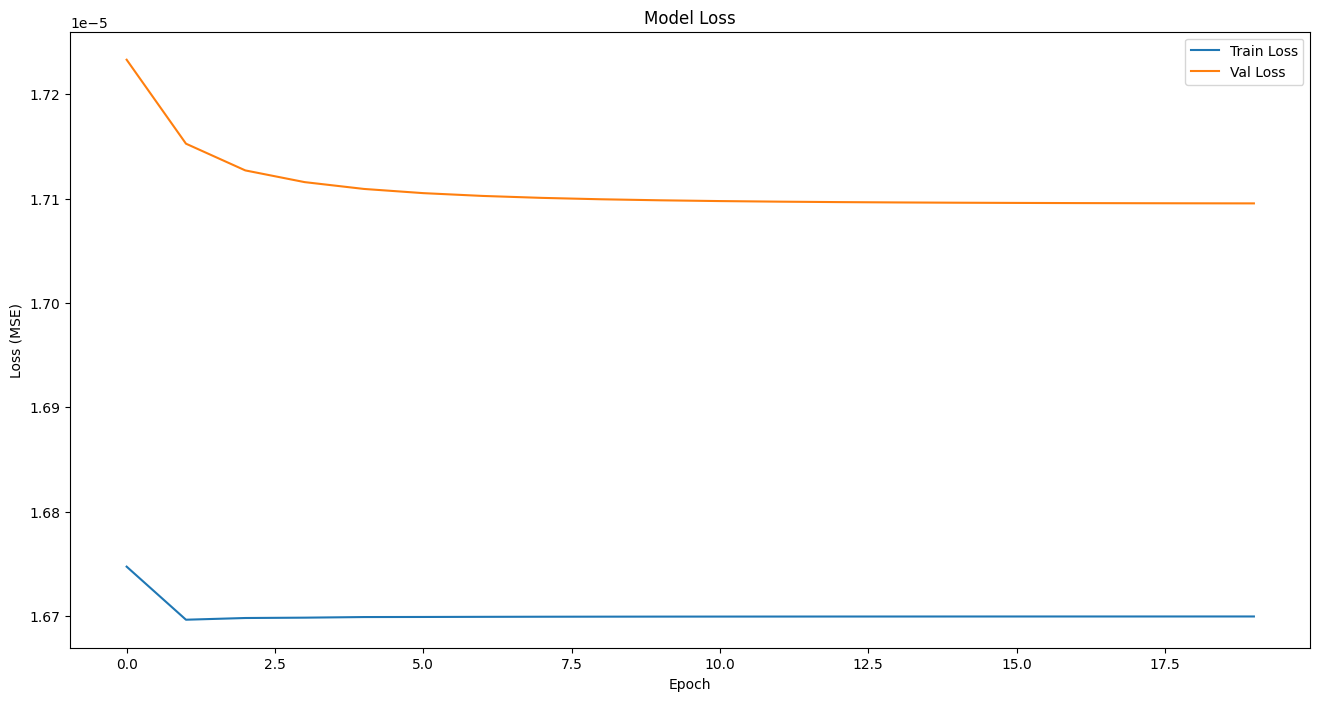

In [30]:
plt.figure(figsize=(16, 8))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [31]:
print("Test Set Evaluation")
results = model2.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Test Set Evaluation
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5061e-05 - mae: 0.0025 
Test MSE: 1.5061355952639133e-05
Test MAE: 0.00252712843939662


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


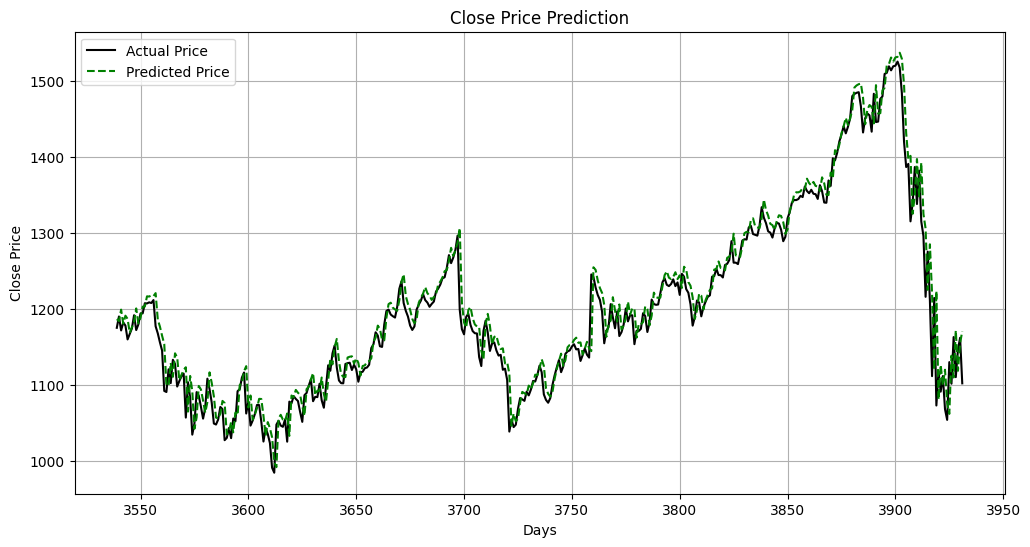

In [32]:
y_pred = model2.predict(X_test)
df_result2 = inverseTransform(y_pred, y_test, df, df_close_tf)

plt.figure(figsize=(12, 6))
plt.grid()
plt.xlabel('Days')
plt.ylabel('Close Price')

plt.plot(df_result2.index, df_result['real'], 'black', label='Actual Price')
plt.plot(df_result2.index, df_result['pred'], 'green', label='Predicted Price', linestyle='--')

plt.title('Close Price Prediction')
plt.legend()
plt.show()

# 1d) Evaluation

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_true = df_result['real'].values
y_pred = df_result['pred'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100

print("Baseline Performance Metrics")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAPE : {mape:.3f}%")

Baseline Performance Metrics
MAE  : 17.706
RMSE : 25.993
MAPE : 1.503%


In [34]:
y_true2 = df_result2['real'].values
y_pred2 = df_result2['pred'].values

mae2 = mean_absolute_error(y_true, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y_true, y_pred2))
mape2 = np.mean(np.abs((y_true - y_pred2) / np.where(y_true == 0, 1, y_true))) * 100

print("Modified Performance Metrics")
print(f"MAE  : {mae2:.3f}")
print(f"RMSE : {rmse2:.3f}")
print(f"MAPE : {mape2:.3f}%")

Modified Performance Metrics
MAE  : 15.867
RMSE : 24.232
MAPE : 1.348%


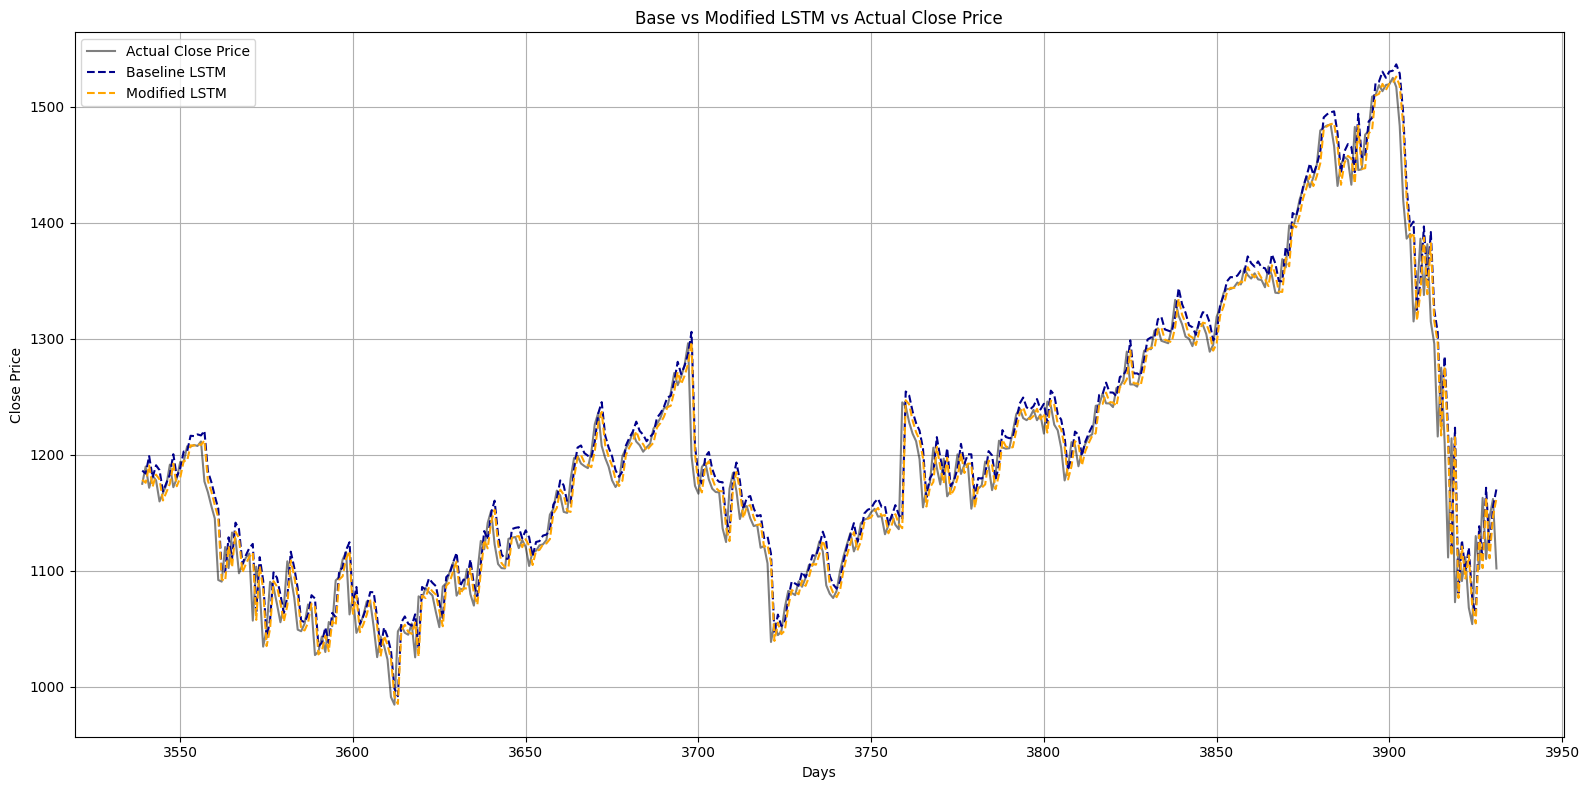

In [35]:
plt.figure(figsize=(16, 8))

plt.plot(df_result.index, y_true, label='Actual Close Price', color='black', alpha=0.5)
plt.plot(df_result.index, df_result['pred'], label='Baseline LSTM', color='darkblue', linestyle='--')
plt.plot(df_result2.index, df_result2['pred'], label='Modified LSTM', color='orange', linestyle='--')

plt.title('Base vs Modified LSTM vs Actual Close Price')
plt.xlabel('Days')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()